1. Consulter Iris dataset et identifier le type initial du problème ? régression ? classification multiclasse ou binaire ? 
    - Classification multiclasse

2. Quel est l’objectif des instructions ligne 8 à la ligne 13 ?
    - Objectif :
        - Transformer le problème à 3 classes
        - En un problème binaire

3. Quel est l’intérêt de la fonction train_test_split? Chercher le rôle de ses paramètres : test_size? Random_state?
    - Séparer les données en :
        - Ensemble d’entraînement (train)
        - Ensemble de test
    - Pour vérifier si le modèle généralise bien

4. À quoi correspond le score1 et le score2 et quelle est la différence entre les deux ?
    - score1: Accuracy sur test set, score2: Accuracy sur le train set 

    - Interprétation importante
        1. Si train >> test → surapprentissage (overfitting)
        2. Si les deux sont faibles → sous-apprentissage (underfitting)
        3. Si les deux sont élevés et proches → bon modèle

5. Réexecuter l’expérimentation en variant test_size par 0.3, 0.4 et 0.5 et noter les scores correspondants ?
    - Quand tu augmentes test_size :
        - Le nombre de données d’entraînement diminue
        - Le modèle peut devenir moins stable
        - Les scores peuvent varier davantage

6. Pourquoi la fonction cross_val_score est utilisé dans la ligne 35? Changer le paramètre cv et examiner les résultats obtenus ?
    - Avec cv=5 :
        - On divise le train set en 5 parties
        - On entraîne sur 4
        - On teste sur 1
        - On répète 5 fois
        - On obtient 5 scores

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [5]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = []

In [7]:
for e in iris.target:
    if e == 0: y += [0]
    else: y += [1]

Text(0, 0.5, 'y')

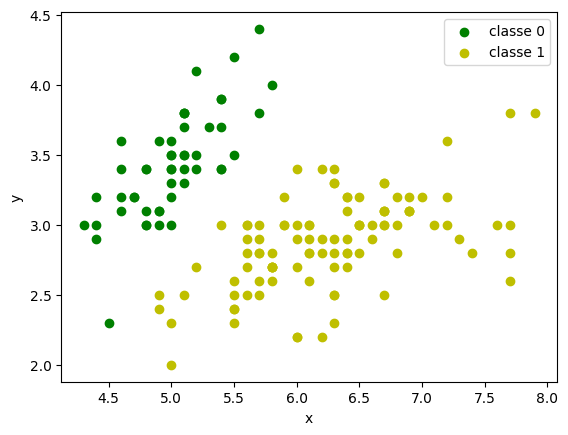

In [8]:
y = np.array(y)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='g')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='y')
plt.legend(labels= ("classe 0", "classe 1"));
plt.xlabel("x")
plt.ylabel("y")

In [15]:
model = LogisticRegression(C=1e20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

In [16]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+20
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
score1 = model.score(x_test, y_test)
score2 = model.score(x_train, y_train)
print("score sur test-set =" + str(score1 * 100) + '%')
print("score sur train-set =" + str(score2 * 100) + '%')
theta0 = model.intercept_
theta1 = model.coef_[0][0]
theta2 = model.coef_[0][1]
iries_to_predict = [[5.5, 2.5], [7, 3], [3, 2], [5, 3]]
print(model.predict(iries_to_predict))
score=cross_val_score(model, x_train, y_train, cv=3, scoring='accuracy')
print(score)
print(f"{score.mean() * 100:.3f}")

score sur test-set =97.33333333333334%
score sur train-set =100.0%
[1 1 0 0]
[0.96 1.   1.  ]
98.667


In [21]:
def fct_reg_logistic(x1,x2):
    return (theta0) + theta1*x1 + (theta2*x2)

In [22]:
print([fct_reg_logistic(e[0],e[1]) for e in iries_to_predict])

[array([64.36557281]), array([145.13085531]), array([-115.43309263]), array([-52.93591056])]
